<a href="https://colab.research.google.com/github/laodeazwaraiman/tugas2ml/blob/main/MIDai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Library berhasil di-import!")

Library berhasil di-import!


In [24]:
# Load dataset
df = pd.read_csv('Walmart.csv')

# Data Understanding
print("--- 5 Data Teratas ---")
display(df.head())
print("\n--- Info Dataset ---")
df.info()
print("\n--- Statistik Deskriptif ---")
display(df.describe())

--- 5 Data Teratas ---


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB

--- Statistik Deskriptif ---


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [25]:
# 1. Mengubah format tanggal dan ekstraksi fitur
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.drop('Date', axis=1, inplace=True)

# 2. Cek Missing Values
print("Jumlah Missing Values:\n", df.isnull().sum())

# 3. Menangani Outlier pada target (Weekly_Sales) menggunakan metode IQR
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Weekly_Sales'] < (Q1 - 1.5 * IQR)) | (df['Weekly_Sales'] > (Q3 + 1.5 * IQR)))]

print(f"\nUkuran data setelah preprocessing: {df.shape}")

Jumlah Missing Values:
 Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Day             0
Month           0
Year            0
dtype: int64

Ukuran data setelah preprocessing: (6401, 10)


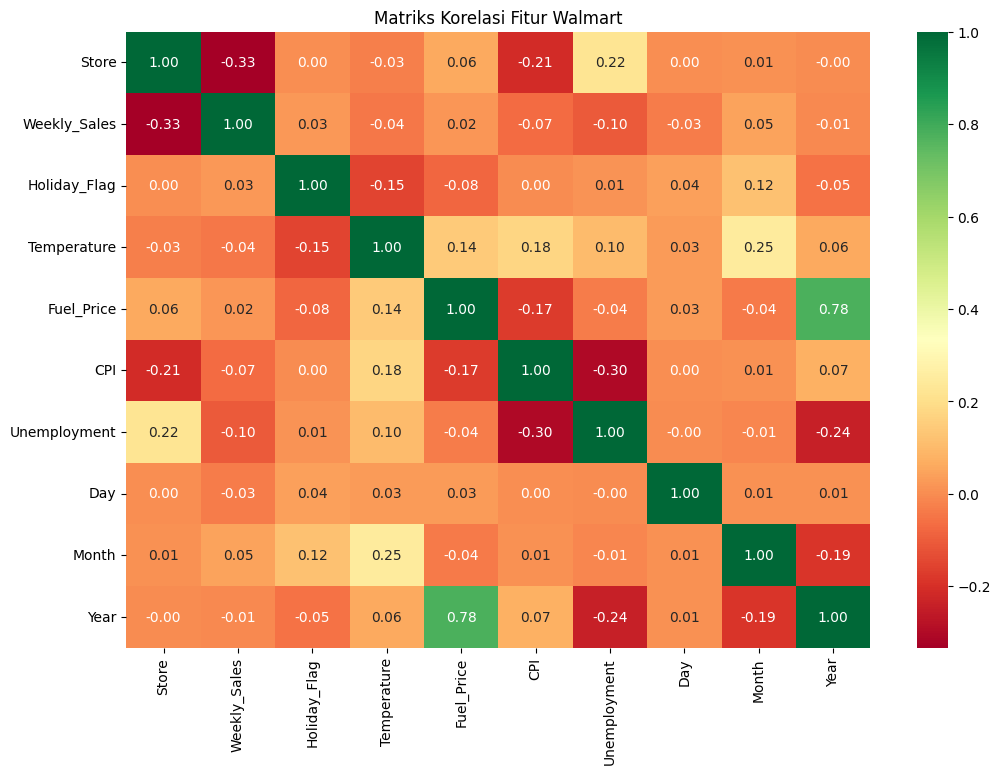

In [26]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Matriks Korelasi Fitur Walmart")
plt.show()

In [30]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('Weekly_Sales', axis=1)
y = df['Weekly_Sales']

# Rata-rata target untuk menghitung persentase error
y_mean = y.mean()

# Definisi Splitting
ratios = [(0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]
split_names = ["70:30", "80:20", "90:10"]

# Algoritma: Decision Tree
model = DecisionTreeRegressor(random_state=42)

# Parameter Grid untuk Tuning
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

results = []

for i, (train_p, test_p) in enumerate(ratios):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_p, random_state=42)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Grid Search
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    best_dt_model = grid_search.best_estimator_

    # Prediksi
    y_pred = best_dt_model.predict(X_test_scaled)

    # Evaluasi Metrik
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Menghitung Persentase Error terhadap rata-rata
    mae_pct = (mae / y_mean) * 100
    rmse_pct = (rmse / y_mean) * 100

    results.append({
        'Splitting': split_names[i],
        'R2 Score (Akurasi)': f"{round(r2 * 100, 2)}%",
        'MAE (%)': f"{round(mae_pct, 2)}%",
        'RMSE (%)': f"{round(rmse_pct, 2)}%",
        'Best Max Depth': grid_search.best_params_['max_depth']
    })

# Tampilkan hasil dalam bentuk Tabel
df_summary = pd.DataFrame(results)
print("--- Hasil Eksperimen Decision Tree (Persentase) ---")
display(df_summary)

--- Hasil Eksperimen Decision Tree (Persentase) ---


,Splitting,R2 Score (Akurasi),MAE (%),RMSE (%),Best Max Depth
0,70:30,92.94%,7.25%,14.23%,None
1,80:20,94.32%,6.8%,12.97%,None
2,90:10,95.37%,6.4%,12.13%,None


<Figure size 1400x800 with 0 Axes>

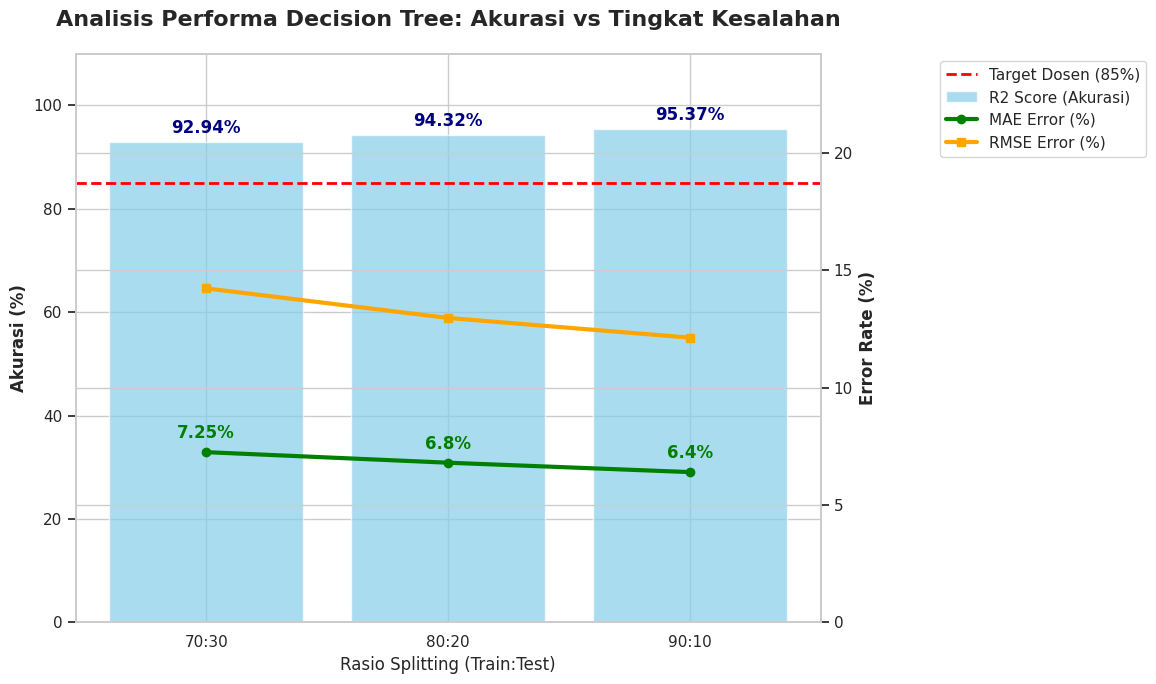


--- ket: ---
1. Performa terbaik ditemukan pada split 90:10 dengan akurasi 95.37%.
2. Tingkat kesalahan rata-rata (MAE) terendah adalah 6.4% dari total penjualan.


In [33]:
# Set style agar terlihat profesional
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

# 1. Menyiapkan data untuk visualisasi (menghapus tanda % agar bisa diplot sebagai angka)
plot_df = df_summary.copy()
plot_df['R2_Numeric'] = plot_df['R2 Score (Akurasi)'].str.replace('%', '').astype(float)
plot_df['MAE_Numeric'] = plot_df['MAE (%)'].str.replace('%', '').astype(float)
plot_df['RMSE_Numeric'] = plot_df['RMSE (%)'].str.replace('%', '').astype(float)

# Pembuatan Subplot (1 Bar Chart untuk Akurasi, 1 Line Chart untuk Error)
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Visualisasi Bar Chart (R2 Score / Akurasi) ---
bars = ax1.bar(plot_df['Splitting'], plot_df['R2_Numeric'], color='skyblue', alpha=0.7, label='R2 Score (Akurasi)')
ax1.set_ylabel('Akurasi (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rasio Splitting (Train:Test)', fontsize=12)
ax1.set_ylim(0, 110)

# Tambahkan garis target dosen (85%)
ax1.axhline(85, ls='--', color='red', linewidth=2, label='Target Dosen (85%)')

# --- Visualisasi Line Chart (MAE & RMSE) ---
# Menggunakan Axis yang berbeda (twinx) untuk persentase error
ax2 = ax1.twinx()
ax2.plot(plot_df['Splitting'], plot_df['MAE_Numeric'], marker='o', color='green', linewidth=3, label='MAE Error (%)')
ax2.plot(plot_df['Splitting'], plot_df['RMSE_Numeric'], marker='s', color='orange', linewidth=3, label='RMSE Error (%)')
ax2.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(plot_df['RMSE_Numeric']) + 10)

# Penambahan Label Angka di atas Bar Akurasi
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}%', ha='center', va='bottom', fontweight='bold', color='navy')

# Penambahan Label Angka di titik Line Chart
for i, txt in enumerate(plot_df['MAE_Numeric']):
    ax2.annotate(f'{txt}%', (plot_df['Splitting'][i], plot_df['MAE_Numeric'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', color='green', fontweight='bold')

# Penggabungan Legend dari kedua Axis
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.15, 1))

plt.title("Analisis Performa Decision Tree: Akurasi vs Tingkat Kesalahan", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n--- ket: ---")
best_idx = plot_df['R2_Numeric'].idxmax()
print(f"1. Performa terbaik ditemukan pada split {plot_df.loc[best_idx, 'Splitting']} dengan akurasi {plot_df.loc[best_idx, 'R2 Score (Akurasi)']}.")
print(f"2. Tingkat kesalahan rata-rata (MAE) terendah adalah {plot_df['MAE_Numeric'].min()}% dari total penjualan.")
